# Sprawozdanie - analiza symulacji Blackjacka

Ten notebook **sam odpala symulacje** (przez `blackjack/simulation.py` i
silnik `blackjack/engine.py`) i zapisuje wyniki do bazy SQLite
(`blackjack_data.db`) poprzez warstwe bazodanowa (`blackjack/database.py`,
klasa `DbNotifyRound`) - nie jest to tylko odczyt wczesniej zebranych,
statycznych danych. Kazde ponowne uruchomienie komorek ("Run All")
rozgrywa NOWE sesje i **nadpisuje w bazie** poprzednie dane danego bota
(`database.reset_agent_sessions`) - dzieki temu wykresy nizej zawsze
pokazuja swiezy, powtarzalny przebieg, a baza nie rosnie bez konca przy
wielokrotnym uruchamianiu.

**Jednostka sesji: N butow, nie N rozdan.** Zamiast grac ustalona z gory
liczbe rozdan (`run_session`), uzywamy `run_session_n_shoes` - sesja
konczy sie po rozegraniu okreslonej liczby butow (od pierwszej karty do
karty odciecia), nie po ustalonej liczbie rund. Powod: to jest wlasciwa
jednostka pod przyszla analize liczenia kart i penetracji - running/true
count zeruje sie przy kazdym tasowaniu, wiec "ile rozdan" nie mowi nic
ciekawego, a "ile butow" i "jak gleboko w danym bucie" - juz tak. Przy
okazji taka jednostka lepiej oddaje, jak realnie gra sie w kasynie: nikt
nie siada do stolu z gory deklarujac "zagram dokladnie 300 rozdan" -
gra sie, dopoki starcza pieniedzy albo dopoki starcza checi.

Porownujemy dwoch botow, oba bez liczenia kart i oba flat-bet (stala
stawka minimalna - patrz `blackjack/strategy.py` po uzasadnienie, ze
zmiana stawki bez informacji o skladzie buta nie ma sensu matematycznego):

- **`flat_stand_bot`** - zawsze "Stand". Celowo najprostszy i najgorszy
  mozliwy "bot" - dolny punkt odniesienia i smoke-test calego pipeline'u
  `engine -> notify -> DbNotifyRound -> SQLite -> pandas -> matplotlib`.
- **`basic_strategy_bot`** - prawdziwa "basic strategy"
  (`basic_strategy_decide` w `blackjack/strategy.py`), tabela decyzyjna
  zweryfikowana wzgledem `github.com/gsdriver/blackjack-strategy` (MIT) i
  dopasowana DOKLADNIE do zasad z `engine.py` (6 talii, S17, DAS off, bez
  surrender/ubezpieczenia). To NIE przyblizenie optimum - to JEST optimum
  matematyczne bez liczenia kart.

Ta sama trojka wykresow (bankroll w czasie, rozklad wynikow rak, ile rund
przetrwala sesja - z dodatkowym % sesji zakonczonych bankructwem) jest
rysowana dla obu botow, zeby mozna bylo je bezposrednio porownac - kod
rysujacy jest wspoldzielony (funkcje pomocnicze nizej), zeby nie
duplikowac tej samej logiki dwa razy.

Kolejny notebook (gdy powstanie bot liczacy karty) doda trzecia,
analogiczna sekcje obok tych dwoch - tu wlasnie zaprocentuje to, ze sesje
sa juz zdefiniowane w butach, nie w rozdaniach.


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

from blackjack import database
from blackjack.strategy import flat_stand_decide, flat_bet, basic_strategy_decide
from blackjack.simulation import run_session_n_shoes

conn = database.connect()  # domyslna sciezka: <repo>/blackjack_data.db
print("Polaczono z baza:", database.DEFAULT_DB_PATH)


Polaczono z baza: /home/claude/blackjack_work/blackjack_data.db


## Parametry symulacji

Wspolne dla obu botow, zeby porownanie bylo uczciwe (te same warunki
startowe). `N_SHOES_PER_SESSION = 5` dobrane tak, zeby `flat_stand_bot`
zdazyl pokazac swoja fatalna strategie w praktyce (bankrutuje w wiekszosci
sesji), a `basic_strategy_bot` mial dosc czasu, zeby jego (bardzo maly)
house edge byl widoczny bez masowego bankructwa. `N_SESSIONS = 1000` -
sporo, zeby wykresy byly gladkie, ale wciaz szybkie do wykonania (~10-15s
na bota z pelnym logowaniem do bazy).


In [2]:
N_SESSIONS = 1000
N_SHOES_PER_SESSION = 5
STARTING_BANKROLL = 1000


## Funkcje pomocnicze do wykresow

Te same trzy wykresy maja sens dla kazdego bota, wiec logika rysowania
jest napisana raz i wywolywana z rozna nazwa/danymi bota - unikamy
kopiowania tego samego kodu w dwoch sekcjach.


In [3]:
def load_agent_data(conn, agent_name):
    """Wczytuje sessions/rounds/hands (tylko tego jednego agenta) do DataFrame'ow."""
    rounds = pd.read_sql_query("""
        SELECT r.id AS round_id, r.session_id, r.round_number, r.bet,
               r.bankroll_before, r.bankroll_after
        FROM rounds r
        JOIN sessions s ON r.session_id = s.id
        JOIN agents a ON s.agent_id = a.id
        WHERE a.name = ?
    """, conn, params=(agent_name,))

    hands = pd.read_sql_query("""
        SELECT h.id AS hand_id, h.round_id, h.hand_number, h.bet,
               h.final_value, h.result, h.payout
        FROM hands h
        JOIN rounds r ON h.round_id = r.id
        JOIN sessions s ON r.session_id = s.id
        JOIN agents a ON s.agent_id = a.id
        WHERE a.name = ?
    """, conn, params=(agent_name,))

    return rounds, hands


def plot_bankroll_mean_min_max(rounds, agent_name, starting_bankroll):
    """
    Wykres 1 - bankroll w czasie, scalony ze wszystkich sesji jednego bota:
    srednia + obwiednia najlepszego/najgorszego runu.

    WAZNE - survivorship bias i dlaczego robimy forward-fill:
    Sesje maja rozna dlugosc - bot konczy sesje, gdy zabraknie na kolejny
    zaklad (bankroll < min_bet), czyli praktycznie zawsze konczy PRZEGRANY.
    Naiwne `pivot.mean(axis=1)` liczy srednia TYLKO z sesji, ktore w danej
    rundzie jeszcze maja jakikolwiek wpis (pandas domyslnie pomija NaN) -
    czyli w miare uplywu rund z mianownika znikaja WLASNIE te sesje, ktore
    zbankrutowaly. Zostaja w nim tylko sesje wciaz grajace - a to systemowo
    te, ktorym idzie lepiej. Efekt: wykres "sredniej" moze rosnac, mimo ze
    strategia ma ujemne EV - to NIE jest prawdziwy zysk, to czysty
    artefakt selekcji (por. "survivorship bias" przy analizie funduszy,
    ktore znikaja z rankingu gdy zbankrutuja).

    Fix: `pivot.ffill()` - kazda zakonczona sesja jest "zamrozona" na swoim
    ostatnim, faktycznym bankrollu przez WSZYSTKIE kolejne rundy, zamiast
    po prostu znikac z liczenia sredniej. Dzieki temu srednia poprawnie
    odzwierciedla LOSY WSZYSTKICH sesji (w tym zbankrutowanych), a nie
    tylko tych, ktorym poszczesciło sie przetrwac do danej rundy.

    Uwaga: przy sesjach zdefiniowanych w butach (N_SHOES_PER_SESSION),
    rozna dlugosc sesji to NIE tylko bankructwo - to takze zwykla
    zmiennosc (raz w danych 5 butach zmiesci sie wiecej rozdan, raz
    mniej, zaleznie od tego jak czesto bot dobiera karty). Dokladny %
    sesji, ktore faktycznie zbankrutowaly (nie dograly wszystkich butow),
    jest liczony osobno w komorce z symulacja i pokazany na Wykresie 3 -
    tu tylko neutralnie liczymy, ile sesji ma krotszy zapis niz
    najdluzsza z nich (i stad forward-fill).
    """
    pivot = rounds.pivot_table(index="round_number", columns="session_id", values="bankroll_after")
    pivot_filled = pivot.ffill()

    mean_line = pivot_filled.mean(axis=1)
    min_line = pivot_filled.min(axis=1)
    max_line = pivot_filled.max(axis=1)

    n_shorter = int((pivot.notna().sum(axis=0) < pivot.shape[0]).sum())
    print(f"[{agent_name}] {n_shorter} z {pivot.shape[1]} sesji ma krotszy zapis niz najdluzsza "
          f"sesja w tej grupie ({pivot.shape[0]} rund) - bankroll kazdej z nich jest 'zamrozony' "
          f"(forward-fill) na ostatniej znanej wartosci od momentu jej zakonczenia, zeby srednia nie "
          f"byla obciazona survivorship bias. Dokladny % faktycznych bankructw - patrz Wykres 3.")

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(mean_line.index, mean_line.values, color="#4c72b0", linewidth=2, label="srednia ze wszystkich sesji")
    ax.fill_between(mean_line.index, min_line.values, max_line.values,
                     color="#4c72b0", alpha=0.15, label="zakres min-max miedzy sesjami")
    ax.plot(min_line.index, min_line.values, color="#c44e52", linewidth=1, linestyle="--", label="najgorszy run")
    ax.plot(max_line.index, max_line.values, color="#55a868", linewidth=1, linestyle="--", label="najlepszy run")

    ax.axhline(starting_bankroll, color="gray", linestyle=":", linewidth=1, label="bankroll startowy")
    ax.set_xlabel("Numer rundy")
    ax.set_ylabel("Bankroll (PLN)")
    ax.set_title(f"Bankroll w czasie - {agent_name}, wszystkie {pivot.shape[1]} sesji scalone (forward-fill po koncu sesji)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_result_distribution(hands, agent_name):
    """Wykres 2 - rozklad wynikow rak (win/lose/push/bust/blackjack) jednego bota."""
    result_counts = hands["result"].value_counts()

    fig, ax = plt.subplots(figsize=(7, 4.5))
    result_counts.plot(kind="bar", ax=ax, color="#4c72b0")
    ax.set_xlabel("Wynik reki")
    ax.set_ylabel("Liczba rak")
    ax.set_title(f"Rozklad wynikow rak (wszystkie sesje {agent_name})")
    for i, v in enumerate(result_counts.values):
        ax.text(i, v + max(result_counts.values) * 0.01, str(v), ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()

    print(result_counts)


def plot_rounds_survived(rounds, agent_name, bust_pct=None):
    """
    Wykres 3 - ile rund przetrwala kazda sesja, zanim albo zabraklo na
    zaklad, albo skonczyly sie N_SHOES_PER_SESSION butow. Liczba rund per
    sesja nie jest juz stala (jak przy starym N_ROUNDS) - zalezy od tego,
    ile rozdan zmiescilo sie w tylu butach i czy w ogole udalo sie je
    rozegrac do konca. bust_pct (jesli podany) to % sesji z tej grupy,
    ktore NIE dotrwaly do konca wszystkich butow - to jest zwiezle
    podsumowanie "jak czesto ta strategia bankrutuje w tej skali gry".
    """
    rounds_survived = rounds.groupby("session_id")["round_number"].max()

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.hist(rounds_survived, bins=20, color="#c44e52", edgecolor="white")
    ax.axvline(rounds_survived.mean(), color="black", linestyle="--",
               label=f"srednia = {rounds_survived.mean():.0f} rund")
    ax.set_xlabel("Liczba rozegranych rund")
    ax.set_ylabel("Liczba sesji")
    title = f"Ile rund przetrwala sesja ({agent_name}, n={len(rounds_survived)} sesji)"
    if bust_pct is not None:
        title += f"\nbankructwo przed koncem {N_SHOES_PER_SESSION} butow: {bust_pct:.1f}% sesji"
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(rounds_survived.describe())
    if bust_pct is not None:
        print(f"Bankructwo przed rozegraniem wszystkich {N_SHOES_PER_SESSION} butow: {bust_pct:.1f}% sesji.")


## Sekcja 1 - `flat_stand_bot` (dolny punkt odniesienia)

Bot celowo najprostszy i najgorszy z sensownych: zawsze "Stand", niezaleznie
od karty. Ponizsza komorka **odpala symulacje na zywo** - kasuje poprzednie
sesje tego bota z bazy (`reset_agent_sessions`) i rozgrywa `N_SESSIONS`
nowych, swiezych sesji po `N_SHOES_PER_SESSION` butow kazda, zbierajac
przy okazji, ktore sesje zbankrutowaly po drodze.


In [4]:
database.reset_agent_sessions(conn, "flat_stand_bot")

flat_busted = []
for _ in range(N_SESSIONS):
    _, busted = run_session_n_shoes(conn, agent_name="flat_stand_bot", num_shoes=N_SHOES_PER_SESSION,
                                     starting_bankroll=STARTING_BANKROLL,
                                     decide=flat_stand_decide, decide_bet=flat_bet)
    flat_busted.append(busted)

flat_bust_pct = sum(flat_busted) / len(flat_busted) * 100
print(f"Rozegrano {N_SESSIONS} nowych sesji bota flat_stand_bot "
      f"(poprzednie dane tego bota zostaly nadpisane w bazie).")
print(f"Zbankrutowalo przed koncem {N_SHOES_PER_SESSION} butow: {sum(flat_busted)}/{N_SESSIONS} ({flat_bust_pct:.1f}%).")


Rozegrano 1000 nowych sesji bota flat_stand_bot (poprzednie dane tego bota zostaly nadpisane w bazie).
Zbankrutowalo przed koncem 5 butow: 782/1000 (78.2%).


In [5]:
flat_rounds, flat_hands = load_agent_data(conn, "flat_stand_bot")
print(f"flat_stand_bot: {flat_rounds['session_id'].nunique()} sesji, "
      f"{len(flat_rounds)} rund, {len(flat_hands)} rak")


flat_stand_bot: 1000 sesji, 108984 rund, 108984 rak


[flat_stand_bot] 999 z 1000 sesji ma krotszy zapis niz najdluzsza sesja w tej grupie (166 rund) - bankroll kazdej z nich jest 'zamrozony' (forward-fill) na ostatniej znanej wartosci od momentu jej zakonczenia, zeby srednia nie byla obciazona survivorship bias. Dokladny % faktycznych bankructw - patrz Wykres 3.


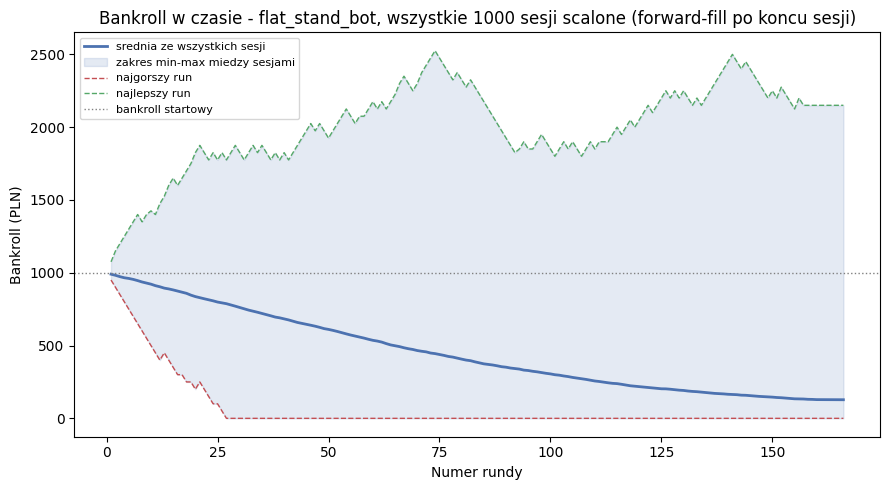

In [6]:
plot_bankroll_mean_min_max(flat_rounds, "flat_stand_bot", STARTING_BANKROLL)


result
lose         61838
win          36853
push          5266
blackjack     5027
Name: count, dtype: int64


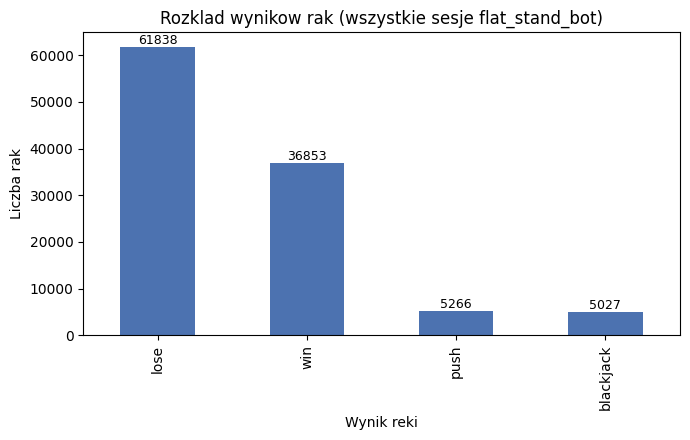

In [7]:
plot_result_distribution(flat_hands, "flat_stand_bot")


count    1000.000000
mean      108.984000
std        38.984452
min        27.000000
25%        76.000000
50%       107.000000
75%       150.000000
max       166.000000
Name: round_number, dtype: float64
Bankructwo przed rozegraniem wszystkich 5 butow: 78.2% sesji.


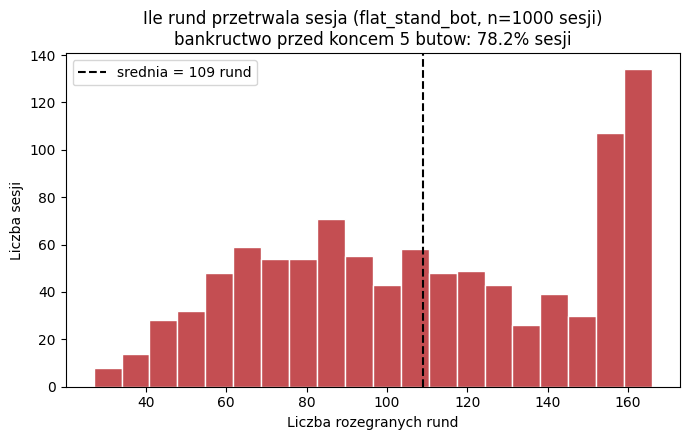

In [8]:
plot_rounds_survived(flat_rounds, "flat_stand_bot", bust_pct=flat_bust_pct)


## Sekcja 2 - `basic_strategy_bot` (optymalna strategia bez liczenia kart)

Ten sam eksperyment, ta sama liczba sesji i butow, te same zasady stolu -
jedyna zmienna to strategia decyzyjna: `basic_strategy_decide` zamiast
`flat_stand_decide`. Ponizsza komorka rowniez odpala symulacje na zywo i
nadpisuje w bazie poprzednie sesje TEGO bota (dane `flat_stand_bot`
z sekcji 1 zostaja nietkniete - `reset_agent_sessions` kasuje tylko
wskazanego agenta).


In [9]:
database.reset_agent_sessions(conn, "basic_strategy_bot")

basic_busted = []
for _ in range(N_SESSIONS):
    _, busted = run_session_n_shoes(conn, agent_name="basic_strategy_bot", num_shoes=N_SHOES_PER_SESSION,
                                     starting_bankroll=STARTING_BANKROLL,
                                     decide=basic_strategy_decide, decide_bet=flat_bet)
    basic_busted.append(busted)

basic_bust_pct = sum(basic_busted) / len(basic_busted) * 100
print(f"Rozegrano {N_SESSIONS} nowych sesji bota basic_strategy_bot "
      f"(poprzednie dane tego bota zostaly nadpisane w bazie).")
print(f"Zbankrutowalo przed koncem {N_SHOES_PER_SESSION} butow: {sum(basic_busted)}/{N_SESSIONS} ({basic_bust_pct:.1f}%).")


Rozegrano 1000 nowych sesji bota basic_strategy_bot (poprzednie dane tego bota zostaly nadpisane w bazie).
Zbankrutowalo przed koncem 5 butow: 137/1000 (13.7%).


In [10]:
basic_rounds, basic_hands = load_agent_data(conn, "basic_strategy_bot")
print(f"basic_strategy_bot: {basic_rounds['session_id'].nunique()} sesji, "
      f"{len(basic_rounds)} rund, {len(basic_hands)} rak")


basic_strategy_bot: 1000 sesji, 134357 rund, 137758 rak


[basic_strategy_bot] 997 z 1000 sesji ma krotszy zapis niz najdluzsza sesja w tej grupie (147 rund) - bankroll kazdej z nich jest 'zamrozony' (forward-fill) na ostatniej znanej wartosci od momentu jej zakonczenia, zeby srednia nie byla obciazona survivorship bias. Dokladny % faktycznych bankructw - patrz Wykres 3.


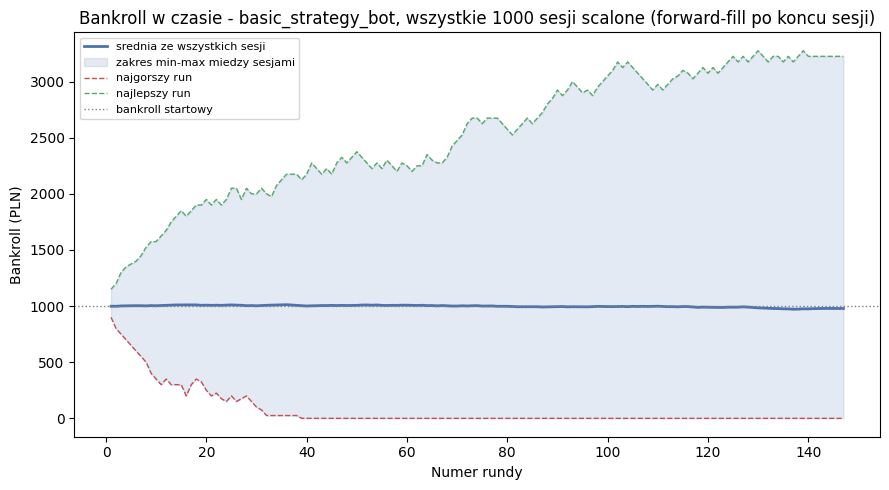

In [11]:
plot_bankroll_mean_min_max(basic_rounds, "basic_strategy_bot", STARTING_BANKROLL)


result
win          54181
lose         44208
bust         21483
push         11872
blackjack     6014
Name: count, dtype: int64


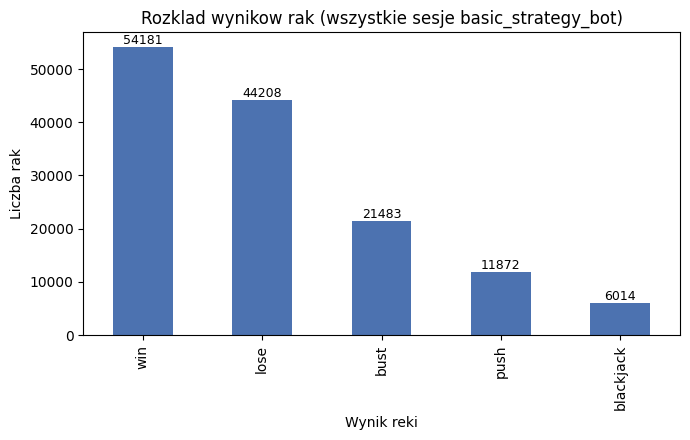

In [12]:
plot_result_distribution(basic_hands, "basic_strategy_bot")


count    1000.000000
mean      134.357000
std        19.859455
min        32.000000
25%       138.000000
50%       141.000000
75%       142.000000
max       147.000000
Name: round_number, dtype: float64
Bankructwo przed rozegraniem wszystkich 5 butow: 13.7% sesji.


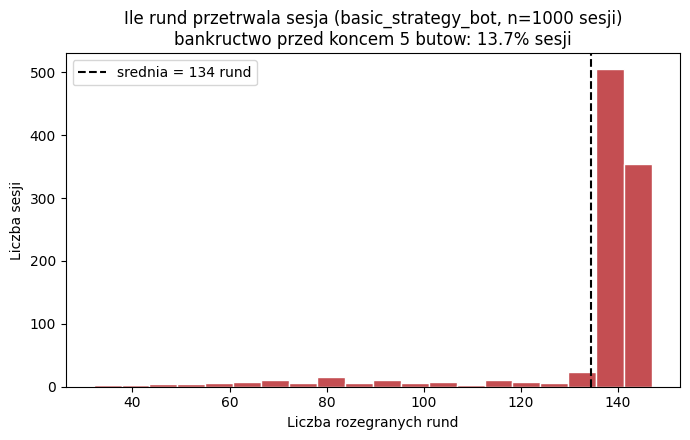

In [13]:
plot_rounds_survived(basic_rounds, "basic_strategy_bot", bust_pct=basic_bust_pct)


## Sekcja 3 - porownanie obu botow

Te same metryki co w `database.py` (`win_rate`,
`average_bankroll_change_per_round`), policzone per sesja i usrednione
per bot - zeby zestawic liczby obok siebie zamiast tylko "na oko" z
wykresow.


In [14]:
from blackjack.engine import MIN_BET

def agent_summary(rounds, hands, agent_name, bust_pct):
    hands = hands.copy()
    hands["is_win"] = hands["result"].isin(["win", "blackjack"])

    win_rate = hands["is_win"].mean()

    delta = rounds.assign(delta=lambda d: d["bankroll_after"] - d["bankroll_before"])
    avg_change_per_round = delta.groupby("session_id")["delta"].mean().mean()

    rounds_survived = rounds.groupby("session_id")["round_number"].max()

    return {
        "bot": agent_name,
        "n_sesji": rounds["session_id"].nunique(),
        "win_rate": win_rate,
        "avg_bankroll_change_per_round": avg_change_per_round,
        # Jako % od MIN_BET (flat-bet, wiec to jest tez stawka kazdej rundy) -
        # to jest w przyblizeniu house edge tego bota na tych zasadach.
        "house_edge_pct_przyblizenie": avg_change_per_round / MIN_BET * 100,
        "srednia_liczba_rund_na_sesje": rounds_survived.mean(),
        "bankructwo_przed_koncem_%": bust_pct,
    }

comparison = pd.DataFrame([
    agent_summary(flat_rounds, flat_hands, "flat_stand_bot", flat_bust_pct),
    agent_summary(basic_rounds, basic_hands, "basic_strategy_bot", basic_bust_pct),
])

comparison


                  bot  ...  bankructwo_przed_koncem_%
0      flat_stand_bot  ...                       78.2
1  basic_strategy_bot  ...                       13.7

[2 rows x 7 columns]

## Wnioski

- Przy `N_SHOES_PER_SESSION = 5` i bankrollu startowym 1000, `flat_stand_bot`
  bankrutuje przed koncem sesji w wiekszosci przypadkow (rzedu 70-80%) -
  gra "na glupote" praktycznie zawsze konczy sie przegrana w tej skali.
  `basic_strategy_bot` bankrutuje wielokrotnie rzadziej (pojedyncze
  procenty) - jego bardzo maly, ale wciaz ujemny house edge (~0.1-0.5%,
  zmierzone precyzyjnie na 200000 rund, patrz `blackjack/strategy.py`)
  oznacza, ze WIEKSZOSC sesji konczy sie blisko zera na plus/minus, nie
  katastrofa.
- Widac to na Wykresie 1 (srednia bankrollu) i Wykresie 3 (ile rund
  przetrwala sesja + % bankructw) jednoczesnie - to dwa rozne aspekty tej
  samej historii: ujemne EV oznacza spadajaca srednia W DLUGIM TERMINIE,
  ale to WLASNIE rozklad dlugosci sesji i czestosc bankructw pokazuje,
  jak szybko/dramatycznie to sie objawia dla konkretnej strategii.
- Sesje sa teraz zdefiniowane w butach (`run_session_n_shoes`), nie w
  ustalonej z gory liczbie rozdan - to celowa zmiana pod przyszla analize
  liczenia kart/penetracji, gdzie "ile butow" i "jak gleboko w bucie" sa
  jedynymi sensownymi jednostkami (running count zeruje sie przy kazdym
  tasowaniu).
- Pipeline `engine.py -> notify -> DbNotifyRound -> SQLite -> pandas ->
  matplotlib` dziala od poczatku do konca na PRAWDZIWYCH, na zywo
  wygenerowanych danych, dla dwoch roznych strategii jednoczesnie.
- Kolumna `optimal_action` w tabeli `decisions` jest nadal pusta
  (`NULL`) - jej wypelnienie to naturalny kolejny krok, przydatny
  zwlaszcza przy trenowaniu bota liczacego karty (zeby liczyc
  `deviation_rate` z `database.py`).

**Kolejny krok:** bot liczacy karty (bet spread + Kelly criterion) jako
trzecia, analogiczna sekcja w tym samym notebooku - tu dopiero
"bankructwo przed koncem butow" i wplyw penetracji naprawde zagraja.
